# Toy System
## System definition
Let $E=[-2,2]$ and let $\nu$ be a probability measure supported on $E$.

Define the process $(X_t)_{t\ge0}$ by:

- **Flow.** For $x\in(-2,2)$,
  $$
  \dot{x}=f(x)=x,\qquad \phi(t,x)=x e^{t}.
  $$

- **Boundary hitting time.**
  $$
  \tau(x)=\inf\{t>0:\phi(t,x)\in\{-1,1\}\}=\ln\!\big(\tfrac{1}{|x|}\big)\quad (x\neq0),
  $$
  and $\tau(0)=+\infty$.

- **Reinsertion rule.** Whenever $X_t$ reaches $\{-2,2\}$ it is instantaneously reset to a random point
  $$
  X_t\sim\nu,
  $$
  independent of the past. Equivalently the jump kernel satisfies $Q(x,A)=\nu(A)$ for $x\in\{-1,1\}$ and Borel $A\subseteq[-1,1]$.

Hence $(X_t)$ is a piecewise-deterministic Markov process on $E$ with flow $f(x)=x$ and reset law $\nu$.


In [70]:
import matplotlib.pyplot as plt
import importlib
import cdv_utils
import numpy as np
from scipy import sparse
import pickle
plt.rcParams['text.usetex'] = True
plt.rcParams['pgf.texsystem'] = "pdflatex"
plt.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath,amsfonts,amssymb,cmbright,standalone}')

importlib.reload(cdv_utils)

/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py:1804: SyntaxWarning: invalid escape sequence '\s'
  title=f"$\sigma = {sigma:.3f}$",
/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py:1879: SyntaxWarning: invalid escape sequence '\s'
  ax.legend(title="$\sigma$", framealpha=1, loc="lower left")
/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py:3249: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")


<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [71]:
from cdv_utils import (plot_lifetime_distributions_lines, diffusion_maps_matrix,
                       expected_escape_times_from_TO, add_scaled_top_axis,
                       spy_col, simulate_trajectories_per_sigma,
                       uniform_reset_sampler_vectorized,
                       uniform_radius_sampler_vectorized,
                       normal_radius_sampler_vectorized,
                       plot_trajectory_with_reinsertions, plot_multiple_sigmas,
                       plot_multiple_trajectories, estimate_pdf_from_sampler,
                       plot_multiple_trajectories_with_pdf_strip,
                       compute_lifetimes_per_sigma,
                       compute_lifetimes_per_sigma_old,
                       constant_reset_sampler_factory,
                       mean_escape_times_via_reinsertion_points,
                       plot_mean_escape_by_reinsertion, f_scientific,
                       tail_integrand_asym,
                       diffusion_maps_matrix_1d,
                       expected_escape_times_from_TO_fast, solve_escape_from_Q,
                       make_L, plot_means_with_inset, maxwell_pdf)

In [25]:
dt = 1e-2
save_every = 1
sigmas = np.linspace(0.0, 0.3, 101, dtype=np.float32)
rng = np.random.default_rng(6942)
var = (np.exp(2.0 * dt) - 1.0) / 2.0
sqrt_var = np.sqrt(var)

In [4]:
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.1], dtype=np.float32),
    dt=dt,
    n_steps=int(5e2) - 1,
    reset_sampler=lambda rng, size: normal_radius_sampler_vectorized(
        rng, size, scale=0.05
    ),
    rng=rng,
    save_every=save_every,
    x0=0.01,
    dtype=np.float32
)

<Axes: title={'center': 'Trajectory with reinsertion on $|x|\\ge 1$'}, xlabel='$t$', ylabel='$x(t)$'>

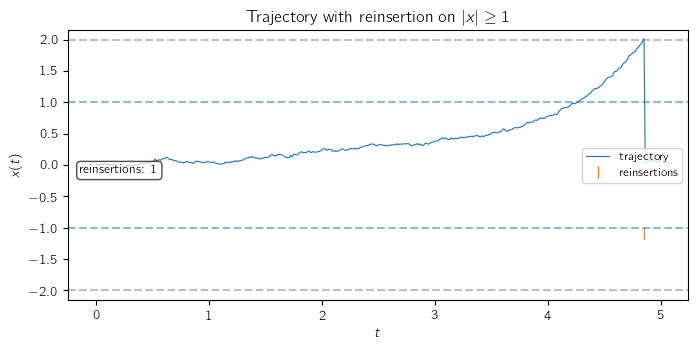

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
reset_times_per_path = [
    times[np.abs(states[:, j]) > 2] for j in range(states.shape[1])]
plot_trajectory_with_reinsertions(
    ax, times, states, reset_times_per_path[0])

## Stochastic Trajectory

In [6]:
# keep rng the same for comparability
rng = np.random.default_rng(42)
times, states, sigma_arr = simulate_trajectories_per_sigma(
    # single sigma -> single column
    sigmas=sigmas,
    dt=dt,
    n_steps=int(1e3) - 1,
    reset_sampler=lambda rng, size: normal_radius_sampler_vectorized(
        rng, size, scale=0.05
    ),
    rng=rng,
    save_every=save_every,
    x0=0.05,
    dtype=np.float32
)

(<Figure size 800x750 with 3 Axes>,
 array([<Axes: title={'center': '$\\sigma = 0.000$'}, ylabel='$x(t)$'>,
        <Axes: title={'center': '$\\sigma = 0.075$'}, ylabel='$x(t)$'>,
        <Axes: title={'center': '$\\sigma = 0.300$'}, xlabel='$t$', ylabel='$x(t)$'>],
       dtype=object))

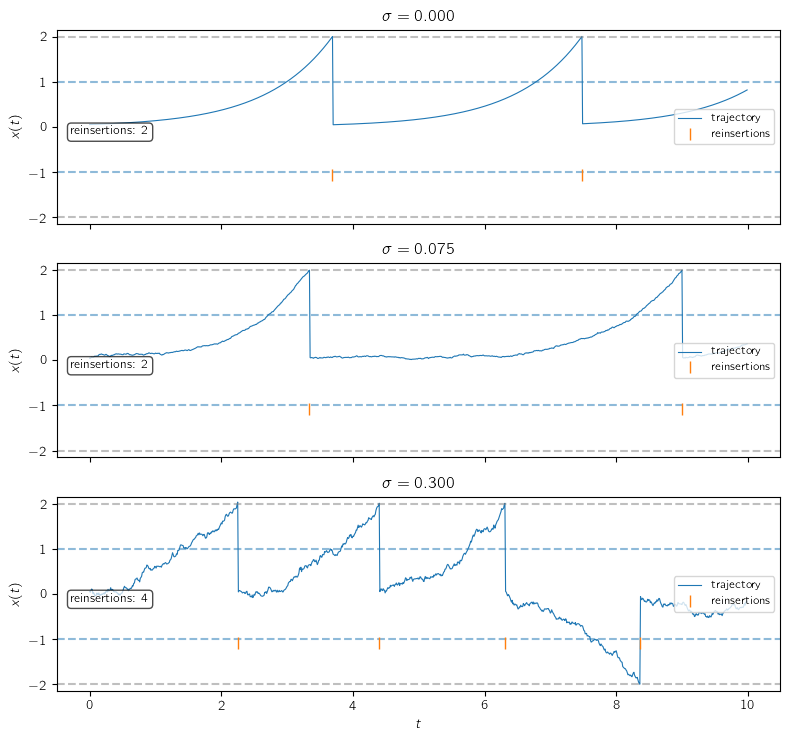

In [7]:
reset_times_per_path = [
    times[np.abs(states[:, j]) > 2] for j in [0, 25, 100]]

plot_multiple_sigmas(times, states[:, [0, 25, 100]],
                     sigma_arr[[0, 25, 100]],
                     n_cols=1, figsize=(8, 2.5), reset_times_per_path=reset_times_per_path)

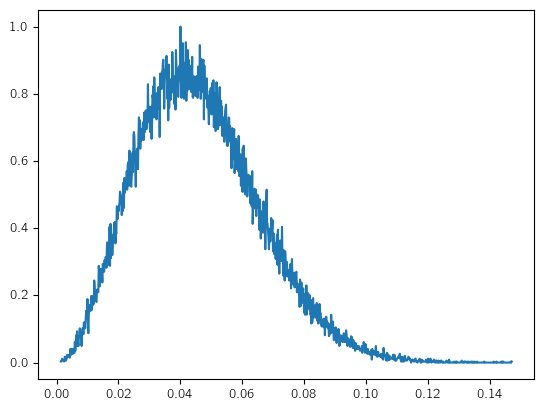

In [8]:
bins, pdf = estimate_pdf_from_sampler(
    normal_radius_sampler_vectorized,
    rng,
    n_bins=1000,
    sampler_kwargs={'scale': 0.05}
)
plt.plot(bins, pdf)
# plt.gca().set_xlim(0.05, 0.1)

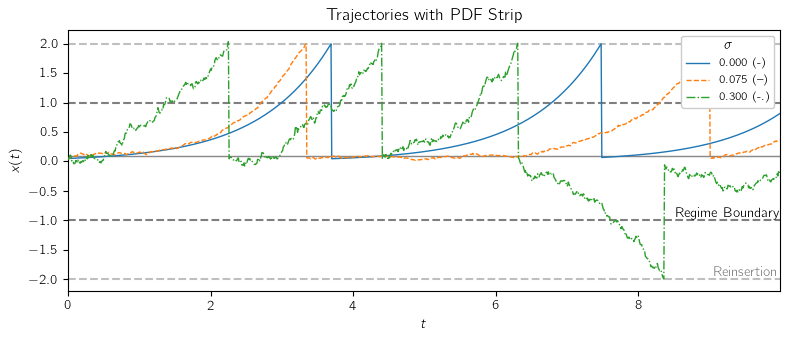

In [9]:
bins, pdf = estimate_pdf_from_sampler(
    uniform_radius_sampler_vectorized,
    rng,
    n_bins=1000,
    sampler_kwargs={'low': 0.05, 'high': 0.1}
)

ax = plot_multiple_trajectories_with_pdf_strip(
    ax=None, times=times, states=states[:, [0, 25, 100]],
    labels=[f"{sigma_arr[i]:.3f}" for i in [0, 25, 100]], pdf_bins=bins, pdf_values=pdf,
    title="Trajectories with PDF Strip")

# ax.set_ylim([0, 0.2])

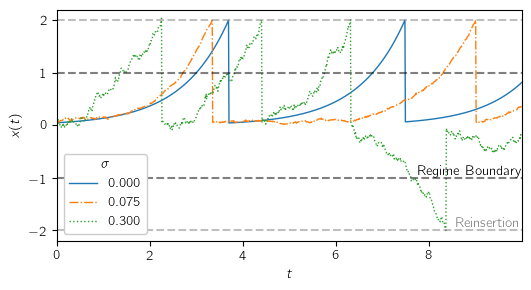

In [10]:
fig, ax = plot_multiple_trajectories(ax=None, times=times,
                                     states=states[:, [
                                         0, 25, 100]],
                                     labels=[
                                         f"{sigma_arr[i]:.3f}"
                                         for i in [0, 25, 100]],
                                     text_loc="right")
ax.set_xlim(0, times[-1])
plt.savefig("../../Toy.pdf", dpi=600, bbox_inches="tight")

## Stochastic Inertia for individual points

### Monte Carlo Method
- use long trajectories for convergence
- larger dt means tails too high

In [11]:
sigmas = sigmas[::20]

In [73]:
# 3 mins
reinsertion_points = np.linspace(0.01, 0.1, 4)
means, counts = mean_escape_times_via_reinsertion_points(
    sigmas=sigmas,
    reinsertion_points=reinsertion_points,
    dt=dt,
    n_steps=int(1e7) - 1,
    rng=rng,
    save_every=save_every,
    dtype=np.float32
)

### Analytic

In [74]:
means_ana = np.empty_like(means)

for i, x in enumerate(reinsertion_points):
    means_ana[:, i] = [f_scientific(x, .5 * sigma**2) for sigma in sigmas]

### Markov Method
- use lower dt for convergence
- dt too low results in worse tails
- dt too high also results in tails too high; keep 5e-4

In [14]:
dt_lower = 5e-4
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt_lower,
    n_steps=int(1e5) - 1,
    reset_sampler=constant_reset_sampler_factory(0.05, dtype=np.float32),
    rng=rng,
    save_every=save_every,
    x0=1e-4,
    dtype=np.float32
)

In [15]:
first_reset = np.where(np.abs(states[:, 0]) > 2)[0][0]
mini_traj = states[:first_reset, 0]
rp_idx = [np.argmin(np.abs(mini_traj - rp))
          for rp in reinsertion_points]
eps_values = (2 * (dt_lower) * sigmas**2)
blocking_mask = np.where(np.abs(mini_traj) < 1.0)[0]
reinsert_TO = np.empty(
    (sigmas.size, reinsertion_points.size), dtype=np.float64)

In [16]:
mini_traj.shape

(19807,)

In [17]:
states.shape

(100000, 1)

In [151]:
# 4 min

for j, eps in enumerate(eps_values):
    print(f"{j}th eps: {eps}")
    L = make_L(mini_traj, eps)
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    t_escape = solve_escape_from_Q(Q)
    reinsert_TO[j, :] = t_escape[rp_idx]

# with open("reinsert_TO_toy.pkl", "wb") as f:
#     pickle.dump(reinsert_TO, f)

0th eps: 0.0
[sparse-direct] used splu (n=9211, nnz=9210, density=0.0001086).
1th eps: 1.8000001489326678e-08
[iterative] GMRES converged with ILU preconditioner (n=9211, nnz=4758970, density=0.05609).
2th eps: 7.200000595730671e-08
[iterative] GMRES converged with ILU preconditioner (n=9211, nnz=7397056, density=0.08719).
3th eps: 1.6199999208765803e-07
[iterative] GMRES converged with ILU preconditioner (n=9211, nnz=9330785, density=0.11).
4th eps: 2.8800002382922685e-07
[iterative] GMRES converged with ILU preconditioner (n=9211, nnz=10885998, density=0.1283).
5th eps: 4.500000159168849e-07
[iterative] GMRES converged with ILU preconditioner (n=9211, nnz=12199430, density=0.1438).
6th eps: 6.479999683506321e-07
[iterative] GMRES converged with ILU preconditioner (n=9211, nnz=13342561, density=0.1573).
7th eps: 8.819999948173063e-07
[iterative] GMRES converged with ILU preconditioner (n=9211, nnz=14358848, density=0.1692).
8th eps: 1.1520000953169074e-06
[iterative] GMRES converged w

### Plot

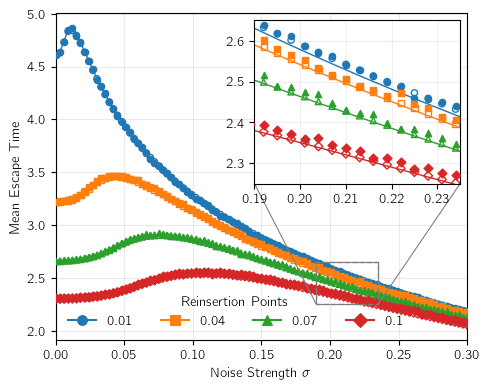

In [77]:
from matplotlib.ticker import MultipleLocator

with open("reinsert_TO_toy.pkl", "rb") as f:
    reinsert_TO = pickle.load(f)  # /2

fig, ax, axins = plot_means_with_inset(
    means_ana=means_ana,
    means=means,
    reinsert_TO=reinsert_TO,
    sigmas=sigmas,
    s=20,
    figsize=(5, 4),
    inset_coords=(0.19, 0.235, 2.25, 2.65),
    inset_width="50%",
    inset_height="50%",
    legend_loc="lower left",
    legend_ncol=4,
    axinset_xticks=MultipleLocator(0.01),
    axinset_yticks=MultipleLocator(0.1),
    reinsertion_points=reinsertion_points,
    dt_lower=dt_lower
)
plt.savefig("../../Toy_AnaVSTraj.pdf", dpi=600, bbox_inches="tight")

## Turn to Regime Lifetimes

### Using Monte Carlo

In [81]:
# we want a smooth curve but not too many points
dt_compare = 5e-2
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=sigmas,
    dt=dt_compare,
    n_steps=int(5e6) - 1,
    reset_sampler=lambda rng, size: normal_radius_sampler_vectorized(
        rng, size, scale=0.05
    ),
    rng=rng,
    save_every=save_every,
    x0=1e-4,
    dtype=np.float32
)

In [82]:
states[np.where(states[:, 0] > 2)[0]].shape

(63273, 101)

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_50587/2440732303.py:4: SyntaxWarning: invalid escape sequence '\s'
  {0: lifetimes}, regime=0, logx=False, xlabel="Noise Strength $\sigma$")


(0.0, 0.30000001192092896)

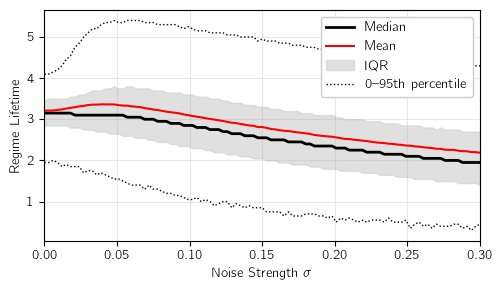

In [83]:
lifetimes = compute_lifetimes_per_sigma(states, sigma_arr)
lifetimes = {k: [vi * dt_compare for vi in v] for k, v in lifetimes.items()}
fig, ax = plot_lifetime_distributions_lines(
    {0: lifetimes}, regime=0, logx=False, xlabel="Noise Strength $\sigma$")
ax.set_xlim(0, sigmas[-1])
# plt.savefig("../../Toy_Lifetimes.pdf", dpi=600)

### Using Markov Chain

In [84]:
rng = np.random.default_rng(420)
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt_compare,
    n_steps=int(2e4) - 1,
    reset_sampler=lambda rng, size: normal_radius_sampler_vectorized(
        rng, size, scale=0.05
    ),
    rng=rng,
    save_every=save_every,
    x0=1e-4,
    dtype=np.float32
)
sneak = 1000
reset_times_per_path = [
    times[:sneak][np.abs(states[:sneak, j]) > 2] for j in range(states.shape[1])
]

<Axes: title={'center': 'Trajectory with reinsertion on $|x|\\ge 1$'}, xlabel='$t$', ylabel='$x(t)$'>

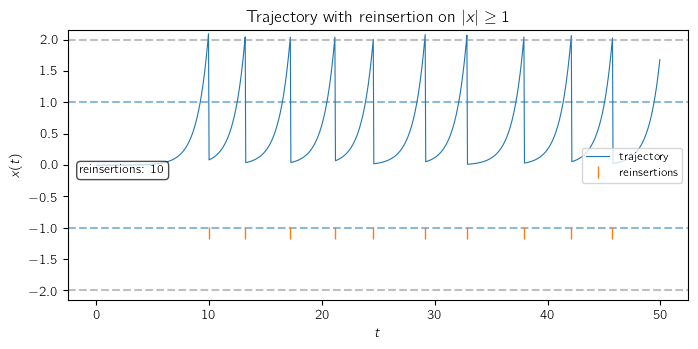

In [85]:
plot_trajectory_with_reinsertions(
    None, times[:sneak], states[:sneak, :], reset_times_per_path[0])

In [86]:
regime_dict = {}
eps_values = (2 * dt_compare * sigmas**2)

blocking_mask = (np.abs(states[:-1]) < 1.0).ravel().astype(bool)
resets = np.where(np.abs(states[:, 0]) > 2)[0] + 1
resets_in_block_idx = np.nonzero(
    np.isin(np.nonzero(blocking_mask)[0], resets))[0]
reset_lifetimes = np.empty((resets_in_block_idx.shape[0], sigmas.shape[0]))

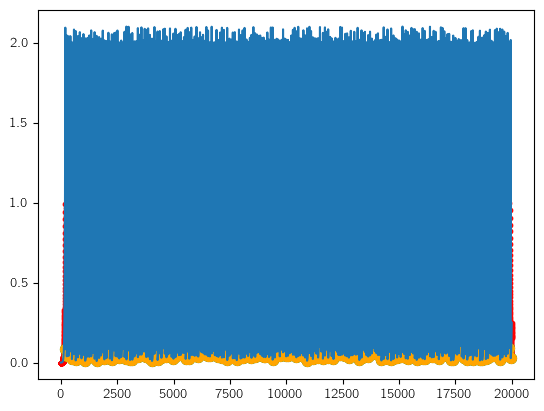

In [87]:
plt.plot(np.arange(states.shape[0]-1), states[:-1])
plt.scatter(np.where(blocking_mask)[0],
            states[:-1][blocking_mask], color='red', s=10)
plt.scatter(resets, states[resets], color='green', s=50)
plt.scatter(np.where(blocking_mask)[0][resets_in_block_idx], states[np.where(
    blocking_mask)[0][resets_in_block_idx]], color='orange', s=50)

In [108]:
np.min(states[resets])

np.float32(0.009670579)

In [88]:
states[resets, 0].shape[0]

250

In [89]:
start_points = normal_radius_sampler_vectorized(
    rng, [states[resets, 0].shape[0]], scale=0.05
)
means_ana_reg = np.zeros((len(sigmas), len(start_points.flatten())))

for i, x in enumerate(start_points.flatten()):
    means_ana_reg[:, i] = [f_scientific(x, .5 * sigma**2) for sigma in sigmas]

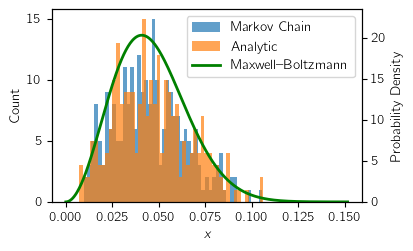

In [90]:
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.hist(states[resets, 0], bins=50,
        alpha=0.7, label="Markov Chain")
ax.hist(start_points, bins=50, alpha=0.7, label="Analytic")
r_max = 5*0.05/np.sqrt(3)
r_grid = np.linspace(0, r_max * 1.05, 400)
axpdf = ax.twinx()
line_pdf, = axpdf.plot(
    r_grid,
    maxwell_pdf(r_grid, 0.05/np.sqrt(3)),
    lw=2,
    label="Maxwell--Boltzmann",
    color="green"
)
ax.set_xlabel("$x$")
ax.set_ylabel("Count")
axpdf.set_ylabel("Probability Density")
axpdf.set_ylim(0, axpdf.get_ylim()[1]*1.1)
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = axpdf.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2)
plt.savefig("../../Toy_StartingPoints.pdf", dpi=600, bbox_inches="tight")

In [49]:
# 21min
for i, eps in enumerate(eps_values):
    print(f"{i}th value: epsilon = {eps:.6f}")

    L = make_L(states, eps)

    Q = L[blocking_mask][:, blocking_mask].tocsr()
    t_escape = solve_escape_from_Q(Q)

    reset_lifetimes[:, i] = t_escape[resets_in_block_idx] * dt_compare

    regime_dict[eps] = (t_escape[resets_in_block_idx] * dt_compare).mean()

0th value: epsilon = 0.000000
[sparse-direct] used splu (n=16288, nnz=16037, density=6.045e-05).
1th value: epsilon = 0.000001
[sparse-direct] used splu (n=16288, nnz=2735344, density=0.01031).
2th value: epsilon = 0.000004
[sparse-direct] used splu (n=16288, nnz=5446318, density=0.02053).
3th value: epsilon = 0.000008
[sparse-direct] used splu (n=16288, nnz=8149123, density=0.03072).
4th value: epsilon = 0.000014
[sparse-direct] used splu (n=16288, nnz=10837644, density=0.04085).
5th value: epsilon = 0.000023
[iterative] GMRES converged with ILU preconditioner (n=16288, nnz=13511916, density=0.05093).
6th value: epsilon = 0.000032
[iterative] GMRES converged with ILU preconditioner (n=16288, nnz=16167424, density=0.06094).
7th value: epsilon = 0.000044
[iterative] GMRES converged with ILU preconditioner (n=16288, nnz=18801482, density=0.07087).
8th value: epsilon = 0.000058
[iterative] GMRES converged with ILU preconditioner (n=16288, nnz=21408038, density=0.08069).
9th value: epsilon

In [97]:
rps = [(v, np.argmin(abs(states[resets] - v)))
       for v in np.percentile(states[resets], [0, 33, 66, 100])]

In [98]:
rps

[(np.float64(0.009670578874647617), np.int64(17)),
 (np.float64(0.03492908209562302), np.int64(30)),
 (np.float64(0.05250200562179089), np.int64(164)),
 (np.float64(0.105546735227108), np.int64(221))]

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_50587/3427167132.py:37: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")


0.009670578874647617
0.03492908209562302
0.05250200562179089
0.105546735227108


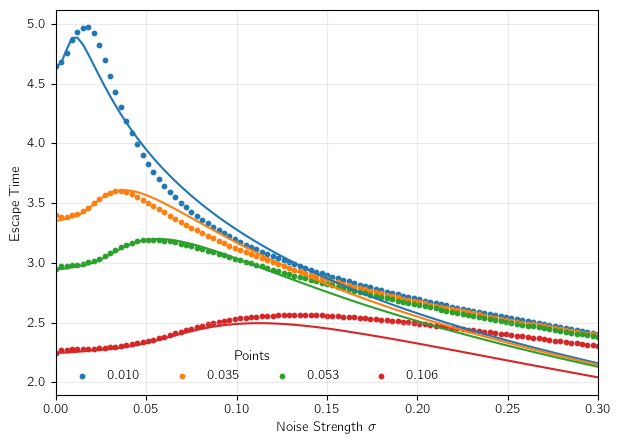

In [ ]:
# plt.plot(sigmas[:10], [regime_dict[eps] for eps in eps_values[:10]], 'x-')
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import Rectangle

size = 10
fig, ax = plt.subplots(figsize=(7, 5))


# x1, x2, y1, y2 = 0.07, 0.11, 2.9, 3.5

# # create inset axes located at top-right of the main axes (40% of width/height)
# axins = inset_axes(ax, width="60%", height="55%", loc="upper right",
#                    bbox_to_anchor=(0.0, 0.0, 1, 1), bbox_transform=ax.transAxes)

# # set the data limits for the inset
# axins.set_xlim(x1, x2)
# axins.set_ylim(y1, y2)

# select some resets
for i, rp_i in enumerate(rps):
    color = f"C{i}"   # uses C0, C1, C2, ...
    print(rp_i[0])
    y = [reset_lifetimes[rp_i[1], j] for j in range(sigmas.shape[0])]
    ana = [f_scientific(rp_i[0], .5 * sigma**2)
           for sigma in sigmas]

    ax.scatter(sigmas, y, color=color, s=size,
               label=f"{rp_i[0]:.3f}")
    ax.plot(sigmas, ana, color=color)
    # axins.scatter(sigmas, y, color=color,  s=size,
    #               label=f"{rp_i[0]:.3f}")
    # axins.plot(sigmas, ana, color=color)

ax.grid(alpha=0.25)
ax.legend(loc="lower left", frameon=False, ncols=5, title="Reinsertion Points")
ax.set_xlim(0, sigmas[-1])
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Escape Time")


# axins.tick_params(axis='both', which='major', labelsize=8)
# axins.grid(alpha=0.2)
# axins.xaxis.set_major_locator(plt.MultipleLocator(0.01))
# axins.yaxis.set_major_locator(plt.MultipleLocator(0.2))
# # draw a rectangle on the main axes showing the inset region
# rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
#                  linewidth=1.0, edgecolor='gray', facecolor='none', linestyle='--', zorder=5)
# ax.add_patch(rect)

# # draw connector lines between inset and rectangle (nice visual cue)
# mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", linewidth=0.8)
# plt.title("circles: simulated traj RPs, lines: analytic")
plt.savefig("../../Toy_RP_Comparison.pdf", dpi=600, bbox_inches="tight")

In [53]:
with open("../../Toy_RegimeStates.pkl", "wb") as f:
    pickle.dump(states, f)


with open("./Toy_RegimeTimeTO.pkl", "wb") as f:
    pickle.dump(regime_dict, f)

with open("./Toy_ResetLifetimesTO.pkl", "wb") as f:
    pickle.dump(reset_lifetimes, f)

In [93]:
with open("../../Toy_RegimeStates.pkl", "rb") as f:
    states = pickle.load(f)

with open("./Toy_RegimeTimeTO.pkl", "rb") as f:
    regime_dict = pickle.load(f)

with open("./Toy_ResetLifetimesTO.pkl", "rb") as f:
    reset_lifetimes = pickle.load(f)

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_50587/4218301940.py:39: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_50587/4218301940.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


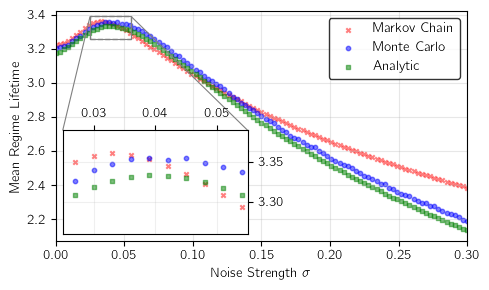

In [ ]:


means = np.array([np.mean(v) for k, v in sorted(lifetimes.items())])
fig, ax = plt.subplots(figsize=(5, 3))


x1, x2, y1, y2 = 0.025, 0.055, 3.26, 3.39

# create inset axes located at top-right of the main axes (40% of width/height)
axins = inset_axes(ax, width="45%", height="45%", loc="lower left",
                   bbox_to_anchor=(0.0, 0.0, 1, 1), bbox_transform=ax.transAxes)

# set the data limits for the inset
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)


ax.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / (dt_compare*2)),
           np.array([regime_dict[k]
                     for k in sorted(regime_dict.keys())]),
           color='red', marker='x', s=10, alpha=.5, label='Markov Chain')
ax.scatter(np.asarray(sorted(lifetimes.keys()), dtype=float), means,
           color='blue', s=10, alpha=0.5, label='Monte Carlo')
ax.scatter(sigmas, means_ana_reg.mean(axis=1),
           color='green', s=10, alpha=0.5, marker="s", label='Analytic')

axins.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / (dt_compare*2)),
              np.array([regime_dict[k]
                        for k in sorted(regime_dict.keys())]),
              color='red', marker='x', s=10, alpha=.5, label='Markov Chain')
axins.scatter(np.asarray(sorted(lifetimes.keys()), dtype=float), means,
              color='blue', s=10, alpha=0.5, label='Monte Carlo')
axins.scatter(sigmas, means_ana_reg.mean(axis=1),
              color='green', s=10, alpha=0.5, marker="s", label='Analytic')
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Regime Lifetime")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, sigmas[-1])
axins.grid(alpha=0.2)
axins.xaxis.set_major_locator(plt.MultipleLocator(0.01))
axins.yaxis.set_major_locator(plt.MultipleLocator(0.05))
axins.tick_params(axis='x', labelbottom=False,
                  bottom=False, top=True, labeltop=True)
axins.tick_params(axis='y', labelleft=False, left=False,
                  right=True, labelright=True)
# draw a rectangle on the main axes showing the inset region
rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                 linewidth=1.0, edgecolor='gray', facecolor='none', linestyle='--', zorder=5)
ax.add_patch(rect)
mark_inset(ax, axins, loc1=2, loc2=1, fc="none", ec="0.5", linewidth=0.8)

ax.legend(facecolor='white', edgecolor='black', loc='best')
plt.tight_layout()
plt.savefig("../../Toy_MeanRegimeLifetimeComparison.pdf",
            dpi=600, bbox_inches="tight")

## Now the TO methods

In [ ]:
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt,
    n_steps=int(2e4) - 1,
    reset_sampler=uniform_radius_sampler_vectorized,
    rng=rng,
    save_every=save_every,
    x0=0.05,
    dtype=np.float32
)
reset_times_per_path = [
    times[np.abs(states[:, j]) > 2] for j in range(states.shape[1])]

### Super small example

In [ ]:
first_reset = np.where(np.abs(states[:, 0]) > 2)[0][0]
mini_traj = states[np.linspace(0, first_reset, num=10, dtype=int), 0]
blocking_mask = np.where(np.abs(mini_traj) < 1.0)[0]
print(mini_traj)

[0.05       0.07534089 0.113525   0.17106149 0.25775847 0.38839507
 0.5852406  0.8818509  1.3287886  2.0022423 ]


<Axes: >

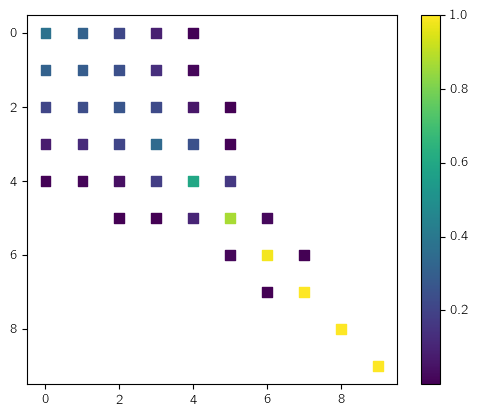

In [ ]:
DMM, A = diffusion_maps_matrix_1d(mini_traj, 1e-2)
coo = DMM.tocoo()
spy_col(DMM)

<Axes: >

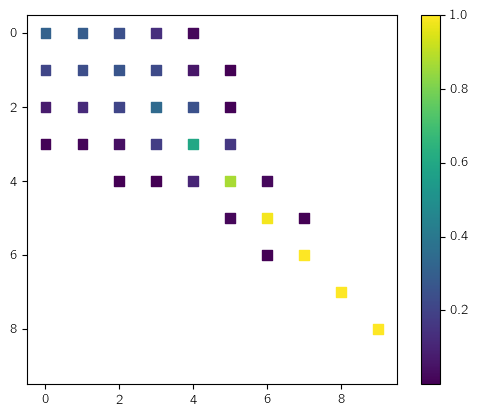

In [ ]:
L = sparse.vstack(
    [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
spy_col(L)

<Axes: >

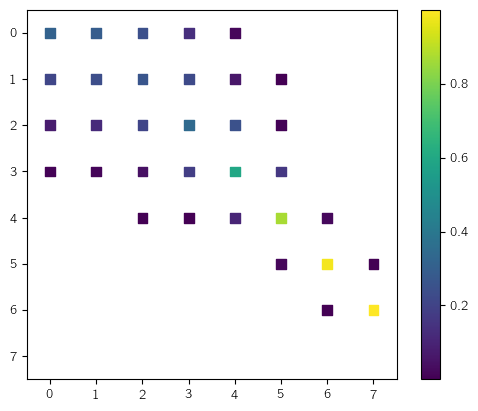

In [ ]:

Q = L[blocking_mask][:,
                     blocking_mask].tocsr()
spy_col(Q)

In [ ]:
from scipy.sparse.linalg import spsolve
I = sparse.eye(Q.shape[0], format='csr')
t_escape = spsolve(I - Q, np.ones(Q.shape[0]))
t_escape

array([7.82736285, 7.68985318, 7.43674014, 6.92945242, 5.84785807,
       3.90873995, 2.23526459, 1.09585399])

In [ ]:
# new dt because of effective subsampling
dt_eff = dt * first_reset/10
eps_values = (2 * (dt_eff) * sigmas**2)

In [ ]:
t_escape = []
for eps in eps_values:
    DMM, A = diffusion_maps_matrix_1d(mini_traj, eps)
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    I = sparse.eye(Q.shape[0], format='csr')
    t_escape.append(spsolve(I - Q, np.ones(Q.shape[0])))
t_escape = np.array(t_escape)  # shape (n_epsilons, n_states_inside)

/tmp/ipykernel_36339/454216667.py:61: RuntimeWarning: invalid value encountered in divide
  A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),


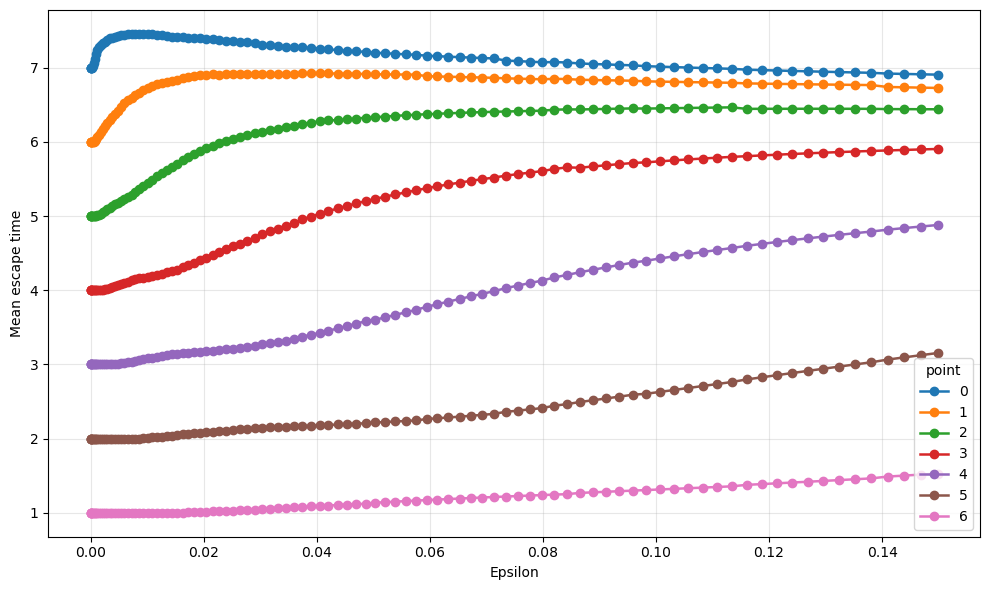

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for j in range(t_escape.shape[1]):
    ax.plot(eps_values, t_escape[:, j], marker='o', linewidth=1.8,
            label=f"{j}")

ax.set_xlabel("Epsilon")
ax.set_ylabel("Mean escape time")
ax.grid(True, alpha=0.3)
ax.legend(title="point", loc="best")
plt.tight_layout()

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_36339/2156026022.py:9: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_36339/2156026022.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Lifetime/$\mathrm{dt}$")


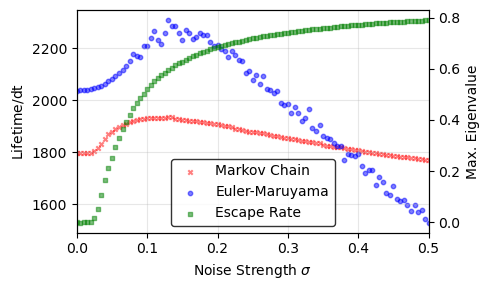

In [ ]:
means = np.array([np.mean(v) for k, v in sorted(lifetimes.items())])
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / (dt_eff*2)),
           np.array([regime_dict[k] * dt_eff/dt
                     for k in sorted(regime_dict.keys())]),
           color='red', marker='x', s=10, alpha=.5, label='Markov Chain')
ax.scatter(np.asarray(sorted(lifetimes.keys()), dtype=float), means,
           color='blue', s=10, alpha=0.5, label='Monte Carlo')
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Lifetime/$\mathrm{dt}$")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.5)
ax_rate = ax.twinx()
ax_rate.scatter(np.sqrt(np.array(sorted(escape_rate_dict.keys()))/(dt_eff*2)),
                np.array([escape_rate_dict[k]
                          for k in sorted(escape_rate_dict.keys())]),
                color='green', marker='s', s=10, alpha=.5, label='Escape Rate')
ax_rate.set_ylabel("Max. Eigenvalue")
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_rate.get_legend_handles_labels()

# Combine them
handles = handles1 + handles2
labels = labels1 + labels2

# Make a single legend
ax.legend(handles, labels, facecolor='white',
          edgecolor='black', loc='lower center')

plt.tight_layout()